In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [20]:
words_data = "/Users/sophiacherkaoui/coding_challenges/words/words-dataset.csv"

In [21]:
df_words = pd.read_csv(words_data)

In [22]:
df_words.drop(columns='Unnamed: 0', inplace=True)

In [23]:
df_words.columns

Index(['words', 'word length', '# unique characters',
       '# non-unique characters', 'contains repeat characters?', '# vowels',
       '# consonants'],
      dtype='str')

In [24]:
x_blue = []
y_blue = []

x_red = []
y_red = []

for i in range(len(df_words['word length'])):
    if df_words['contains repeat characters?'][i] == True:
        x_blue.append(df_words['word length'][i])
        y_blue.append(df_words['# vowels'][i])
    else:
        x_red.append(df_words['word length'][i])
        y_red.append(df_words['# vowels'][i])

Text(0, 0.5, '# of Vowels')

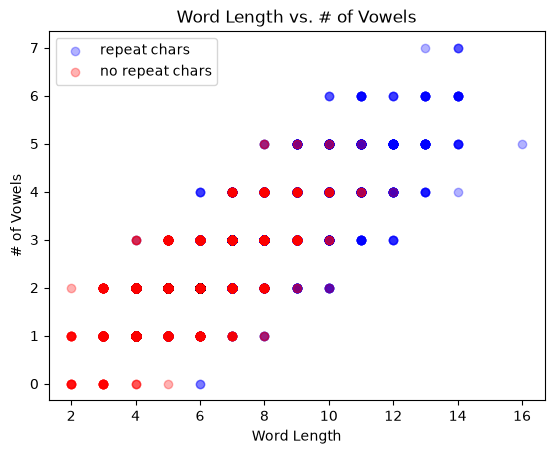

In [25]:
# plot 1: scatter plot relating word length to number of vowels
# indicate whether word contained repeat characters
fig, ax = plt.subplots()
ax.scatter(x_blue, y_blue, color='blue', label='repeat chars', alpha=0.3)
ax.scatter(x_red, y_red, color='red', label='no repeat chars', alpha=0.3)
ax.legend()
ax.set_title('Word Length vs. # of Vowels')
ax.set_xlabel('Word Length')
ax.set_ylabel('# of Vowels')

In [26]:
top_five = df_words.nlargest(n=5, columns=['word length'])

Text(0, 0.5, 'Word length')

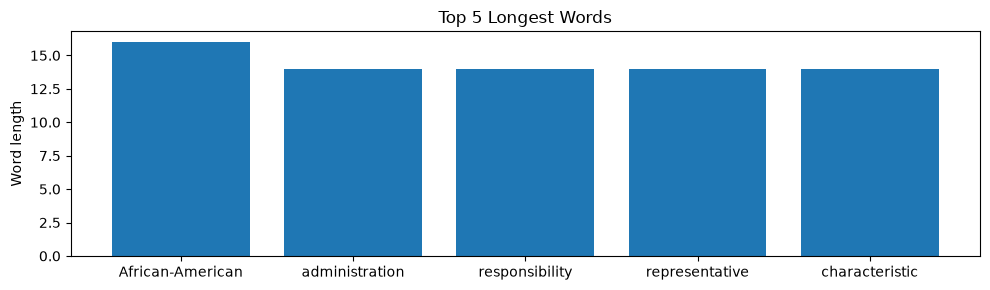

In [27]:
# plot 2: stats on five longest words in dataset
fig, ax = plt.subplots(figsize=(10, 3), layout='tight')
categories = [word for word in top_five['words']]
ax.bar(categories, [l for l in top_five['word length']], )
ax.set_title('Top 5 Longest Words')
ax.set_ylabel('Word length')

(array([2.85714286, 4.99735049, 7.36070606, 9.14925373]),
 array([ 1.,  4.,  8., 12., 16.]),
 <BarContainer object of 4 artists>)

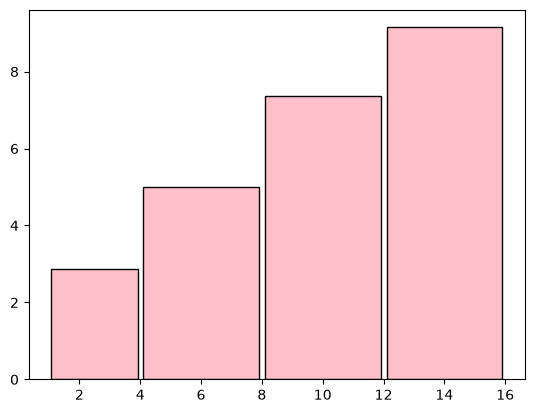

In [28]:
# plot 3: most common # of unique characters based on length of word
grp1 = np.arange(1, 4)
grp2 = np.arange(4, 8)
grp3 = np.arange(8, 12)
grp4 = np.arange(12, 16)

bins = [1, 4, 8, 12, 16]

df_grp1 = df_words[df_words['word length'].isin(grp1)]
df_grp2 = df_words[df_words['word length'].isin(grp2)]
df_grp3 = df_words[df_words['word length'].isin(grp3)]
df_grp4 = df_words[df_words['word length'].isin(grp4)]

grp1_avg = np.mean(df_grp1['# unique characters'])
grp2_avg = np.mean(df_grp2['# unique characters'])
grp3_avg = np.mean(df_grp3['# unique characters'])
grp4_avg = np.mean(df_grp4['# unique characters'])

counts = [grp1_avg, grp2_avg, grp3_avg, grp4_avg]

plt.hist(bins[:-1], bins, weights=counts, color='pink', edgecolor='black', rwidth=0.95)

In [29]:
housing_data = "/Users/sophiacherkaoui/coding_challenges/house_model/housing.csv"

In [30]:
df_housing = pd.read_csv(housing_data)

In [31]:
df_housing.dropna(inplace=True)

Text(0.5, 1.0, 'Population and Median Income')

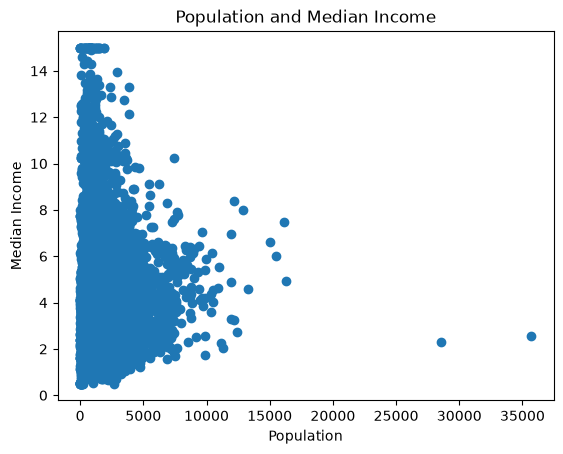

In [32]:
# plot 1: relation of population to median income
x = df_housing['population']
y = df_housing['median_income']

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel("Population")
ax.set_ylabel("Median Income")
ax.set_title("Population and Median Income")

In [33]:
df_housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [34]:
if df_housing['median_house_value'][190] > int(np.mean(df_housing['median_house_value'])):
    print("yes")
else:
    print(df_housing['median_house_value'][900])

197000.0


Text(0, 0.5, 'Latitude')

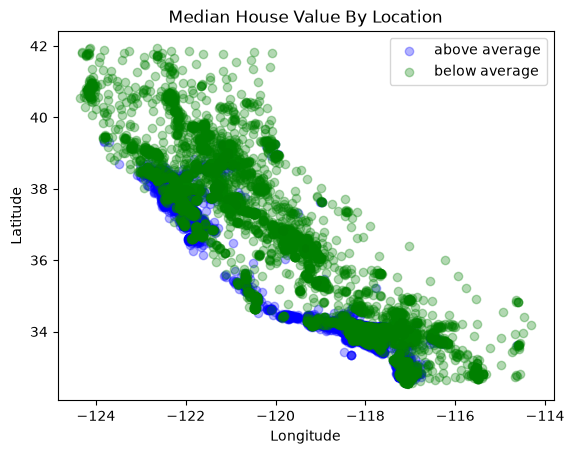

In [37]:
# plot 2: relation of location to high median house value
mean = np.mean(df_housing['median_house_value'])

high = df_housing[df_housing['median_house_value'] > mean]
low = df_housing[df_housing['median_house_value'] <= mean]

fig, ax = plt.subplots()
ax.scatter(high['longitude'], high['latitude'], color='blue', label='above average', alpha=0.3)
ax.scatter(low['longitude'], low['latitude'], color='green', label='below average', alpha=0.3)
ax.legend()
ax.set_title('Median House Value By Location')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

Text(0, 0.5, 'Population')

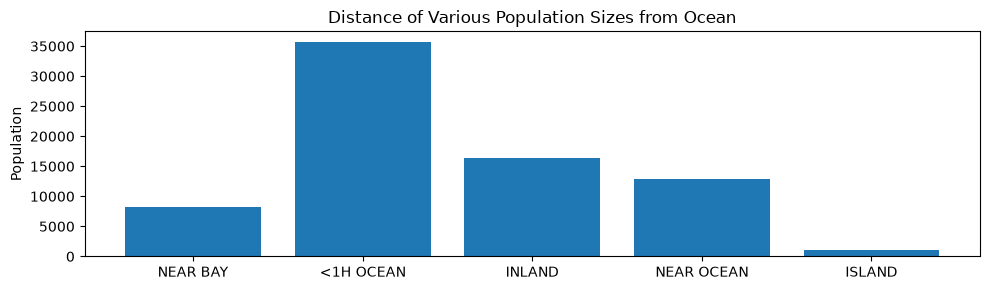

In [44]:
# plot 3: population of towns and ocean proximity
x = df_housing['population']
y = df_housing['ocean_proximity']

fig, ax = plt.subplots(figsize=(10, 3), layout='tight')
categories = ["ISLAND", "NEAR OCEAN", "INLAND", "<1H OCEAN", "NEAR BAY"]
ax.bar(y, x)
ax.set_title('Distance of Various Population Sizes from Ocean')
ax.set_ylabel('Population')